### Top Pharmaceuticals payment data analysis

* Goal: Analysis of gender based payment disparity in pharmaceutical industry
* Scope General data - Segmentation and analysis of pfizer
* Subsidiaries considerd: pfizer, seagen
* Date: 22 November 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_dashboard=pd.read_csv("dashboard_dataset_nov17.csv", low_memory=False)

In [3]:
df_dashboard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6673533 entries, 0 to 6673532
Data columns (total 33 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Unnamed: 0                                                         int64  
 1   Covered_Recipient_Type                                             object 
 2   Teaching_Hospital_Name                                             object 
 3   Covered_Recipient_Profile_ID                                       float64
 4   Covered_Recipient_First_Name                                       object 
 5   Covered_Recipient_Last_Name                                        object 
 6   Covered_Recipient_Primary_Type_1                                   object 
 7   Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name      object 
 8   Total_Amount_of_Payment_USDollars                                  float64
 9   Nu

In [4]:
df_dashboard=df_dashboard.drop(['Unnamed: 0'], axis=1)


In [5]:
df_dashboard['Covered_Recipient_Profile_ID']=df_dashboard['Covered_Recipient_Profile_ID'].astype('object')
df_dashboard.describe()

,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount,Average_payment
count,6.673533e+06,6.673533e+06,6.673533e+06
mean,1.701051e+02,1.023259e+00,1.699443e+02
std,5.890177e+04,5.954720e-01,5.890177e+04
min,1.000000e-02,1.000000e+00,1.000000e-02
25%,1.392000e+01,1.000000e+00,1.388000e+01
50%,1.789000e+01,1.000000e+00,1.784000e+01
75%,2.337000e+01,1.000000e+00,2.330000e+01
max,8.837730e+07,1.270000e+02,8.837730e+07


In [6]:
# To run for each company by replacing df with df_mycom

In [7]:
df_dashboard['Parent_Manufacturer_or_GPO'].unique()


array(['merck', 'astrazeneca', 'novartis', 'abbvie', 'pfizer',
       'johnson & johnson', 'roche', 'gsk', 'bristol myers squibb',
       'gilead', 'vertex', 'novo nordisk', 'eli lilly', 'sanofi',
       'bayer healthcare', 'amgen', 'boehringer',
       'regeneron pharmaceuticals', 'modernatx', 'biontech'], dtype=object)

In [8]:
df_mycom=df_dashboard[df_dashboard['Parent_Manufacturer_or_GPO']=='pfizer']
my_com='pfizer'

In [9]:
### Master set for querying every company

# Total amount and number of transactions
print("Total amount of payments processed in USD for the year 2023 for "+ my_com, df_mycom['Total_Amount_of_Payment_USDollars'].sum(), '$')
print("total number of transactions processed in 2023 for " +my_com, df_mycom['Number_of_Payments_Included_in_Total_Amount'].sum())


Total amount of payments processed in USD for the year 2023 for pfizer 42440815.24999998 $
total number of transactions processed in 2023 for pfizer 545628


In [10]:
# Number of individuals paid using profile ID
print("The number of individuals paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())

The number of individuals paid: 151488


In [11]:
# Number of third parites reciving payments
print("Number of third parties receiving payments", df_mycom['Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value'].nunique())


Number of third parties receiving payments 1235


In [12]:
# All the covered recipient types
df_mycom['Covered_Recipient_Type'].unique()

array(['Covered Recipient Physician',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Teaching Hospital'], dtype=object)

In [13]:
df_mycom['Covered_Recipient_Type'].value_counts()


Covered_Recipient_Type
Covered Recipient Physician                     354426
Covered Recipient Non-Physician Practitioner    190731
Covered Recipient Teaching Hospital                471
Name: count, dtype: int64

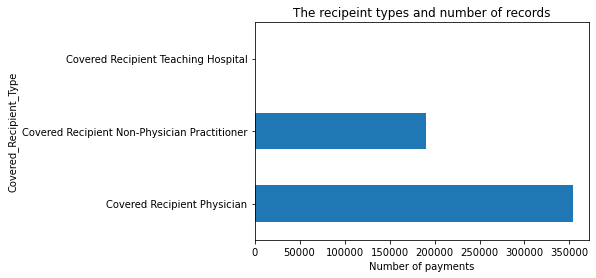

In [14]:
# Covered recipient types and numer of payment records
plt.title('The recipeint types and number of records');
df_mycom['Covered_Recipient_Type'].value_counts().plot(kind='barh')
plt.xlabel('Number of payments');


In [15]:
# Recipient types and total amount pain to each type
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().reset_index()


,Covered_Recipient_Type,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,4680815.36
1,Covered Recipient Physician,33001971.22
2,Covered Recipient Teaching Hospital,4758028.67


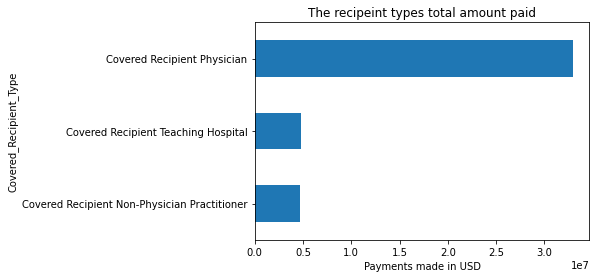

In [16]:
# Covered recipient types and payment amount

plt.title('The recipeint types total amount paid');
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().sort_values().plot(kind='barh')
plt.xlabel('Payments made in USD');


In [17]:
# Payment to teaching hospitals
print("The number of teaching hospitals paid:", df_mycom['Teaching_Hospital_Name'].nunique())


The number of teaching hospitals paid: 131


In [18]:
# Teaching hospitals and related paymants
top_teaching=df_mycom.groupby(['Covered_Recipient_Type', 'Teaching_Hospital_Name'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_teaching.Teaching_Hospital_Name.describe()



count                        131
unique                       131
top       national jewish health
freq                           1
Name: Teaching_Hospital_Name, dtype: object

In [19]:
# Teaching hospitals sorted by total payment amount
print("Teaching hospitals and total payments")
top_teaching


Teaching hospitals and total payments


,Covered_Recipient_Type,Teaching_Hospital_Name,Total_Amount_of_Payment_USDollars
0,Covered Recipient Teaching Hospital,national jewish health,346000.00
1,Covered Recipient Teaching Hospital,brigham and womens hospital,304000.00
2,Covered Recipient Teaching Hospital,scripps mercy hospital,266250.00
3,Covered Recipient Teaching Hospital,hospital of the univ of penna,253974.84
4,Covered Recipient Teaching Hospital,rush university medical center,253512.50
...,...,...,...
126,Covered Recipient Teaching Hospital,iowa methodist medical center,500.00
127,Covered Recipient Teaching Hospital,park nicollet methodist hospital,490.00
128,Covered Recipient Teaching Hospital,north colorado medical center,400.00
129,Covered Recipient Teaching Hospital,cooper university hospital,400.00


In [20]:
# identifying unique individuals using profile ID.
print("Total individuals by profile paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())



Total individuals by profile paid: 151488


In [21]:
print("Gender distribution in healthcare dataset")
gender_dist=df_mycom.groupby(['Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist



Gender distribution in healthcare dataset


,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,F,81035
1,M,70454


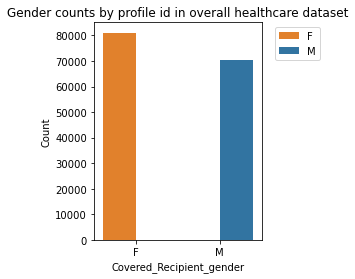

In [22]:
# Plot for gender distribution
my_palette ={"F": "C1", "M": "C0"}
g=sns.barplot(data=gender_dist, x='Covered_Recipient_gender', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender counts by profile id in overall healthcare dataset")
g.figure.set_size_inches(3, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.xticks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [23]:
print("Gender distribution by physicians and non-physicians in Covered recipients")
gender_dist_recipients=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_recipients

Gender distribution by physicians and non-physicians in Covered recipients


,Covered_Recipient_Type,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Covered Recipient Non-Physician Practitioner,F,46205
1,Covered Recipient Non-Physician Practitioner,M,10308
2,Covered Recipient Physician,F,34830
3,Covered Recipient Physician,M,60146


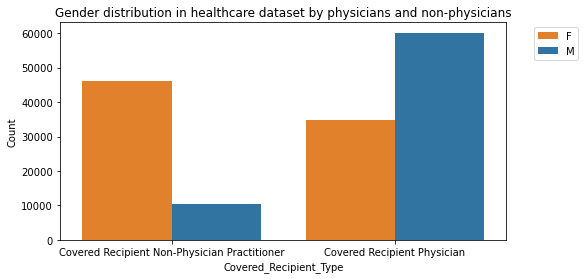

In [24]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_recipients, x='Covered_Recipient_Type', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution in healthcare dataset by physicians and non-physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [25]:
print("Gender distribution amongst physician categories")
gender_dist_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_physicians



Gender distribution amongst physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Chiropractor,F,3
1,Chiropractor,M,7
2,Doctor of Dentistry,F,30
3,Doctor of Dentistry,M,38
4,Doctor of Optometry,F,11
5,Doctor of Optometry,M,21
6,Doctor of Osteopathy,F,4881
7,Doctor of Osteopathy,M,7467
8,Doctor of Podiatric Medicine,F,13
9,Doctor of Podiatric Medicine,M,31


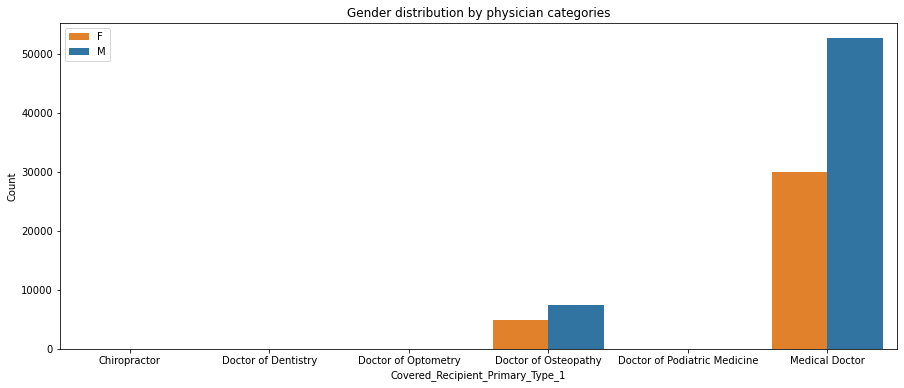

In [26]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by physician categories")
g.figure.set_size_inches(15, 6)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(loc='upper left');



In [27]:
print("Gender distribution amongst non-physician categories")
gender_dist_non_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_non_physicians



Gender distribution amongst non-physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Anesthesiologist Assistant,F,1
1,Certified Nurse-Midwife,F,358
2,Certified Nurse-Midwife,M,16
3,Certified Registered Nurse Anesthetist,F,21
4,Certified Registered Nurse Anesthetist,M,12
5,Clinical Nurse Specialist,F,159
6,Clinical Nurse Specialist,M,11
7,Nurse Practitioner,F,32583
8,Nurse Practitioner,M,5182
9,Physician Assistant,F,13091


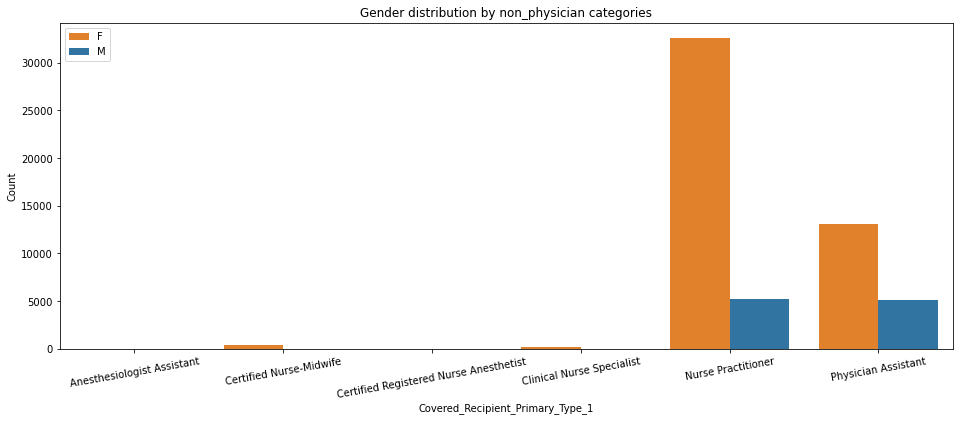

In [28]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_non_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by non_physician categories")
g.figure.set_size_inches(16, 6)
plt.ylabel("Count")
plt.xticks(rotation=10)
# Place the legend outside the plot
plt.legend(loc='upper left');



In [29]:
# Covered recipient types and total payments to each type by gender
print("Total payments by recipients gender")
recipient_gender_payments=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index();
recipient_gender_payments


Total payments by recipients gender


,Covered_Recipient_Type,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Covered Recipient Physician,M,23190057.66
1,Covered Recipient Physician,F,9809315.33
2,Covered Recipient Non-Physician Practitioner,F,3846719.89
3,Covered Recipient Non-Physician Practitioner,M,834061.28


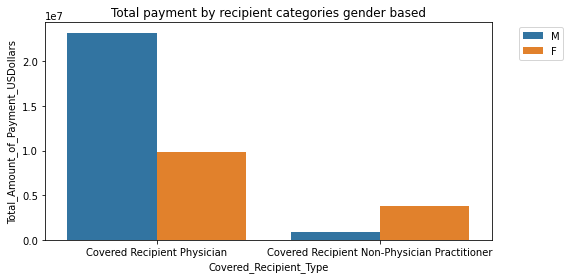

In [30]:
# Plot for gender distribution
g=sns.barplot(data=recipient_gender_payments, x='Covered_Recipient_Type', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by recipient categories gender based")
g.figure.set_size_inches(8, 4)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



## Total payment physicians 

In [31]:
### Total payment split physician profiles
print("The total payment for physician profiles")
physicians_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Total_Amount_of_Payment_USDollars
0,Medical Doctor,31289847.60
1,Doctor of Osteopathy,1658733.99
2,Doctor of Dentistry,26720.77
3,Doctor of Optometry,24334.03
4,Doctor of Podiatric Medicine,1907.90
5,Chiropractor,426.93


In [32]:
### Total payment split physician profiles by gender
print("The total payment for physician profiles")
physicians_gender_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1', 'Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_gender_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Medical Doctor,M,21949284.01
1,Medical Doctor,F,9337965.36
2,Doctor of Osteopathy,M,1205400.49
3,Doctor of Osteopathy,F,453333.50
4,Doctor of Optometry,M,23754.31
5,Doctor of Dentistry,F,16765.22
6,Doctor of Dentistry,M,9955.55
7,Doctor of Podiatric Medicine,M,1366.96
8,Doctor of Optometry,F,579.72
9,Doctor of Podiatric Medicine,F,540.94


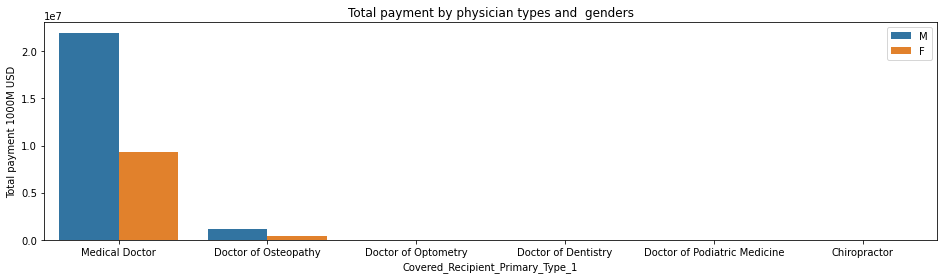

In [33]:
# Plot for gender distribution
g=sns.barplot(data=physicians_gender_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by physician types and  genders")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment 1000M USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Average payments

In [34]:
# Average payment per recipient type.
print("The average payment by per transaction recipient category")
avg=df_mycom.groupby(['Covered_Recipient_Type'])['Average_payment'].mean()
avg


The average payment by per transaction recipient category


Covered_Recipient_Type
Covered Recipient Non-Physician Practitioner       24.541450
Covered Recipient Physician                        93.113855
Covered Recipient Teaching Hospital             10101.971699
Name: Average_payment, dtype: float64

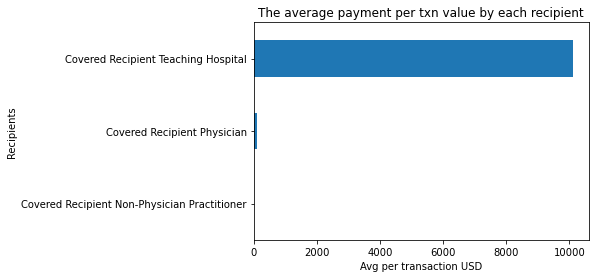

In [35]:
## Plot for average payment per recipient group type
plt.title("The average payment per txn value by each recipient")
avg.plot(kind='barh')
plt.xlabel('Avg per transaction USD')
plt.ylabel('Recipients');


In [36]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average per transaction payment  for recipient types')
gender_recipients_avg=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
   
gender_recipients_avg



Gender based average per transaction payment  for recipient types


,Covered_Recipient_Type,Covered_Recipient_gender,Average_payment
0,Covered Recipient Physician,M,96.207140
1,Covered Recipient Physician,F,86.530132
2,Covered Recipient Non-Physician Practitioner,F,25.013460
3,Covered Recipient Non-Physician Practitioner,M,22.576978


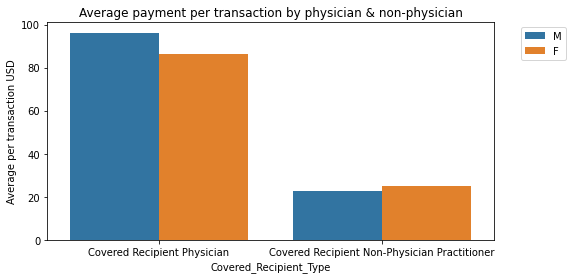

In [37]:
# Plot for gender distribution
g=sns.barplot(data=gender_recipients_avg, x='Covered_Recipient_Type', y='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title("Average payment per transaction by physician & non-physician")
g.figure.set_size_inches(8, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [38]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average transaction value for physician categories')
gender_recipients_avg_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
gender_recipients_avg_payments



Gender based average transaction value for physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Average_payment
0,Doctor of Optometry,M,879.789259
1,Doctor of Dentistry,F,220.595000
2,Doctor of Dentistry,M,132.740667
3,Medical Doctor,M,104.494028
4,Medical Doctor,F,96.525417
5,Doctor of Optometry,F,44.593846
6,Chiropractor,F,43.530000
7,Doctor of Osteopathy,M,39.095761
8,Chiropractor,M,37.042500
9,Doctor of Podiatric Medicine,F,31.820000


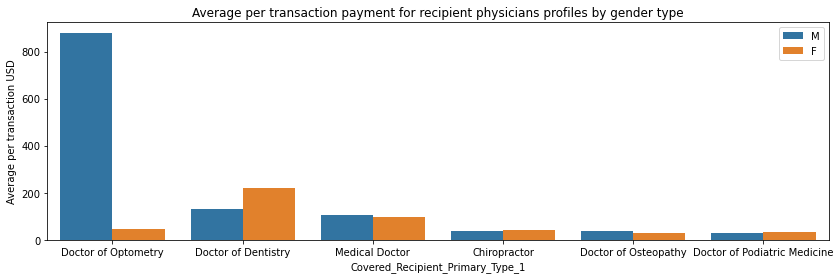

In [39]:
## Plot for average payment per recipient physician primary 1 type
g=sns.barplot(data=gender_recipients_avg_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_gender',palette=my_palette)
g.set_title('Average per transaction payment for recipient physicians profiles by gender type')
g.figure.set_size_inches(14, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Analysis by individuals

In [40]:
print("Total payment distribution per individual")
ind_tot_payments=df_mycom[df_mycom['Covered_Recipient_Profile_ID'].notna()].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_tot_payments


Total payment distribution per individual


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,290561.0,M,2470295.92
1,801195.0,F,806741.52
2,1141924.0,M,222338.00
3,119303.0,F,212069.12
4,59755.0,M,204667.40
...,...,...,...
151484,113706.0,M,1.14
151485,345095.0,M,1.14
151486,251946.0,M,1.14
151487,554491.0,M,1.14


In [41]:
### Physicians 
print("individual payment distribution")
ind_payments_phys=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_payments_phys


individual payment distribution


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,290561.0,M,2470295.92
1,801195.0,F,806741.52
2,1141924.0,M,222338.00
3,119303.0,F,212069.12
4,59755.0,M,204667.40
...,...,...,...
94971,113706.0,M,1.14
94972,251946.0,M,1.14
94973,345095.0,M,1.14
94974,554491.0,M,1.14


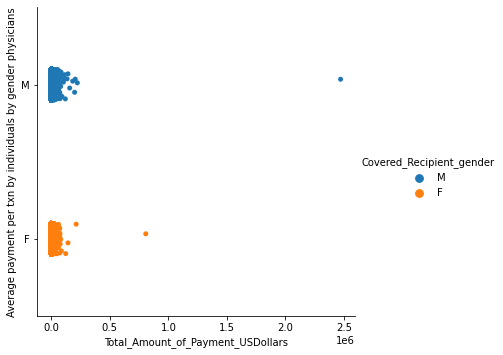

In [42]:
### Plot for gender distribution for physicians
g=sns.catplot(data=ind_payments_phys, y='Covered_Recipient_gender', x='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette)
g.set_titles("{col_name} {col_var}")
plt.ylabel("Average payment per txn by individuals by gender physicians");


#### Analysing top 50 individuals by gender

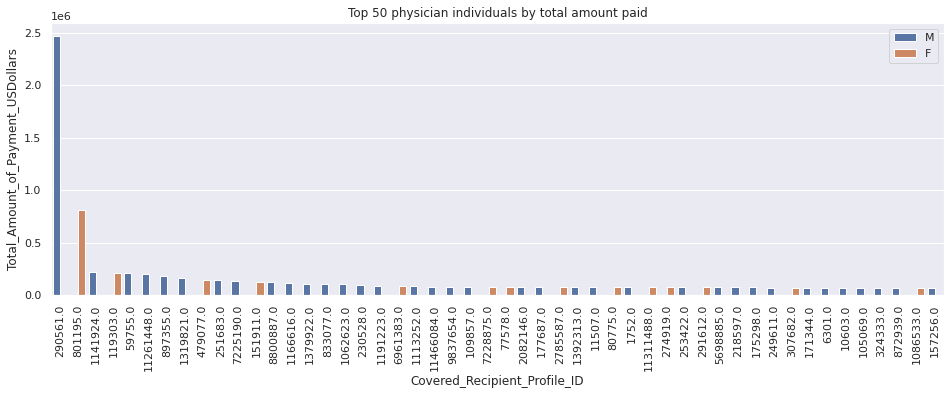

In [43]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=ind_payments_phys[:50], x='Covered_Recipient_Profile_ID', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', 
              order=ind_payments_phys[:50].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID, palette=my_palette)
g.set(title="Top 50 physician individuals by total amount paid")
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');

## Distribution by nature of payments

In [44]:
# Distribution by nature of payments to physicians
nature_payments=df_mycom.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_payments


,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Other_services,12196653.39
1,Food and Beverage,9819809.78
2,Consulting Fee,9268434.66
3,Grant,3959025.94
4,Acquisitions,3277037.44
5,Travel and Lodging,2298040.61
6,Spacerent_teaching_hosp,833158.00
7,Education,445252.03
8,Honoraria,196853.40
9,Royalty or License,91800.00


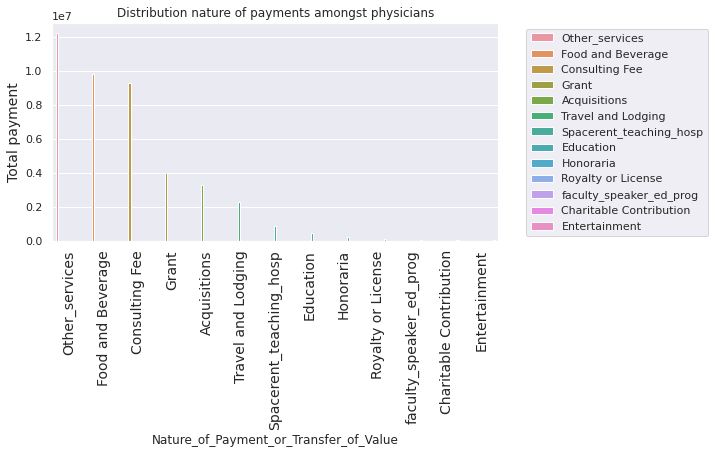

In [45]:
# Nature of payments made
g=sns.barplot(data=nature_payments, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Nature_of_Payment_or_Transfer_of_Value').set_title("Distribution nature of payments amongst physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [46]:
# Distribution by gender for nature of payments
nature_gender=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender


,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Other_services,M,7737209.29
1,Consulting Fee,M,6401002.70
2,Food and Beverage,M,4287474.97
3,Other_services,F,3385586.10
4,Acquisitions,M,2470295.92
5,Consulting Fee,F,2404352.90
6,Food and Beverage,F,2095201.99
7,Travel and Lodging,M,1335563.83
8,Acquisitions,F,806741.52
9,Travel and Lodging,F,681184.22


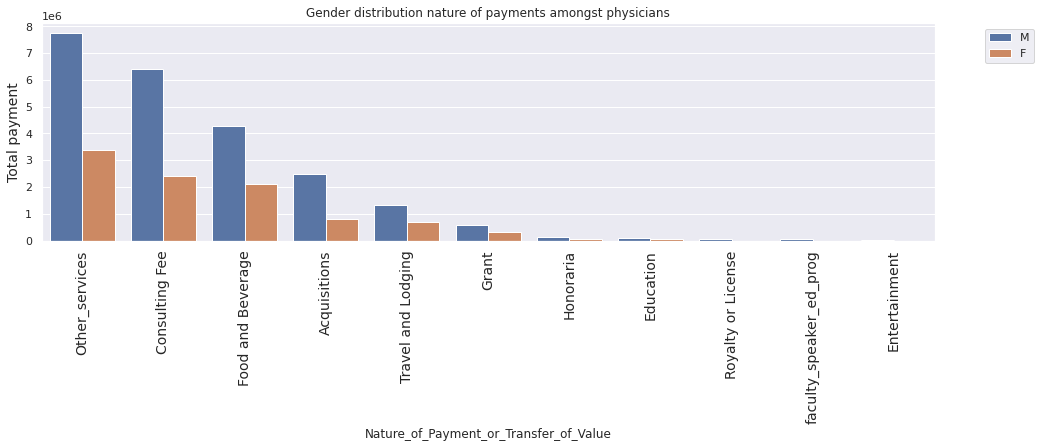

In [47]:
my_palette=my_palette ={"F": "C1", "M": "C0"}

g=sns.barplot(data=nature_gender, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution nature of payments amongst physicians")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

In [48]:
# Distribution by gender for nature of payments
top_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_individual

,Covered_Recipient_Profile_ID,Total_Amount_of_Payment_USDollars
0,290561.0,2470295.92
1,801195.0,806741.52
2,1141924.0,222338.00
3,119303.0,212069.12
4,59755.0,204667.40
...,...,...
94970,345095.0,1.14
94971,113706.0,1.14
94972,554491.0,1.14
94973,251946.0,1.14


In [49]:
# Distribution by gender for nature of payments
nature_gender_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender_individual


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,290561.0,Acquisitions,M,2470295.92
1,801195.0,Acquisitions,F,806741.52
2,1141924.0,Consulting Fee,M,220063.00
3,59755.0,Consulting Fee,M,200312.27
4,11261448.0,Consulting Fee,M,199200.00
...,...,...,...,...
99721,70144.0,Education,M,1.14
99722,576691.0,Education,F,1.14
99723,249132.0,Education,F,1.14
99724,288246.0,Education,F,1.14


In [50]:
## No 1 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==290561.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,290561.0,Acquisitions,M,2470295.92


In [51]:
## No 2 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==801195.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
1,801195.0,Acquisitions,F,806741.52


In [52]:
## No 3 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==1141924.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
2,1141924.0,Consulting Fee,M,220063.0
1919,1141924.0,Other_services,M,2275.0


In [53]:
## No 4 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==119303.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
5,119303.0,Consulting Fee,F,187032.29
274,119303.0,Travel and Lodging,F,18354.79
903,119303.0,Food and Beverage,F,6682.04


In [54]:
# No 5 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==59755.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
3,59755.0,Consulting Fee,M,200312.27
1356,59755.0,Travel and Lodging,M,4189.73
12172,59755.0,Food and Beverage,M,165.40


In [55]:
## Reveivers of royalty
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
24,218597.0,Royalty or License,M,70000.0


In [56]:
# Royalty receiver other txn
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==218597.0]

,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
24,218597.0,Royalty or License,M,70000.0
2604,218597.0,Consulting Fee,M,1200.0


In [57]:
# Receivers of grant
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Grant']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
17,6961383.0,Grant,F,85520.06
18,109857.0,Grant,M,80000.00
19,9837654.0,Grant,M,80000.00
21,7228875.0,Grant,F,80000.00
22,2082146.0,Grant,M,75000.00
23,11311488.0,Grant,F,73084.18
70,11451776.0,Grant,M,43750.00
79,11531549.0,Grant,M,41353.43
87,11287726.0,Grant,M,40000.00
89,8801947.0,Grant,M,39999.96


In [58]:
# Receivers of grant
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Education']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
3165,139236.0,Education,M,610.80
3488,196391.0,Education,M,475.67
3560,4215557.0,Education,F,457.87
3707,176358.0,Education,M,421.93
3950,787374.0,Education,M,383.96
...,...,...,...,...
99720,717322.0,Education,M,1.14
99721,70144.0,Education,M,1.14
99722,576691.0,Education,F,1.14
99723,249132.0,Education,F,1.14


In [59]:
# Honoraria
# Receivers of honoraria
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Honoraria'].sort_values(by='Total_Amount_of_Payment_USDollars')



,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
4498,636850.0,Honoraria,F,331.84
2856,632785.0,Honoraria,M,900.00
2738,802975.0,Honoraria,F,1025.00
2425,350354.0,Honoraria,M,1390.00
2298,277903.0,Honoraria,M,1540.00
2115,5698885.0,Honoraria,M,1890.00
2042,146657.0,Honoraria,M,2000.00
2040,252331.0,Honoraria,M,2000.00
1928,268851.0,Honoraria,F,2250.00
1764,354191.0,Honoraria,M,2658.04


In [60]:
# Receivers of acquisitions
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Acquisitions'].sort_values(by='Total_Amount_of_Payment_USDollars')



,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
1,801195.0,Acquisitions,F,806741.52
0,290561.0,Acquisitions,M,2470295.92


# Summary of observations for Pfizer
* Overall gender ratio is tilted towards females at 53.49%.

**Physicians**
* The female count at physician level is at 36.67%
* Average payment as phycian males is higher than females in optometry, osteopathy, Medical doctor
* females earn higher avg per txn in dentistry, chiropracter, podiatric medicine.


**Non Physicians**
* Gender ratio is reversed. Females are more, females are 81.75%
* Non-physicians females get paid higher on average. 

**Amongst top 50 paid, only 14 are females.**
* Acquisitions were paid to 1 male $2470295.92 and 1 female $ 806741.52 The top earners.
* Other top earners are primarily paid forConsulting and travel lodging.
* 2 males got royalties of 70,000$
* 33 Honoraria were paid varying from $ 331.84 to $40,500. 11 were to females. Max of 40,000 was to a male. Rest all were less than 18K.
* 22 grants were paid, 8 were to females. Highest grant was 85,520$ to a female, followed by 2 males and a female of amount 80,000. Most people got above 20,000$ 
